# STAGE 2: Fast Models Comparison
## Goal: Find the best fast model suitable for real-time edge deployment

1. Loading preprocessed data from Stage 1
2. Training Random Forest model
3. Comparing Random Forest vs Logistic Regression
4. Analyzing inference speed (milliseconds per prediction)
5. Feature importance analysis
6. Making decision for Stage 3


## Section 1: Import Libraries and Load Stage 1 Data

Import libraries and load the preprocessed data from Stage 1.

In [15]:
# Data manipulation
import pandas as pd
import numpy as np
import pickle
import json

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Timing
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported")

All libraries imported


## Section 2: Load Preprocessed Data from Stage 1

Load the scaled data, models, and results from Stage 1.

In [16]:

stage1_data_path = 'D:\sem_7\Research - Copy\stage_experiments\Stage_1_Data_Prep\stage1_preprocessed_data.pkl'
stage1_model_path = 'D:\sem_7\Research - Copy\stage_experiments\Stage_1_Data_Prep\stage1_baseline_model.pkl'
stage1_results_path = 'D:\sem_7\Research - Copy\stage_experiments\Stage_1_Data_Prep\stage1_baseline_results.json'

# Load preprocessed data
stage1_data = pickle.load(open(stage1_data_path, 'rb'))
X_train_scaled = stage1_data['X_train_scaled']
X_test_scaled = stage1_data['X_test_scaled']
y_train = stage1_data['y_train']
y_test = stage1_data['y_test']
scaler = stage1_data['scaler']
X_columns = stage1_data['X_columns']

# Load baseline model
lr_baseline = pickle.load(open(stage1_model_path, 'rb'))

# Load baseline results
with open(stage1_results_path, 'r') as f:
    stage1_results = json.load(f)

print(f"Data loaded successfully")
print(f"\n  Training set: {X_train_scaled.shape[0]} samples, {X_train_scaled.shape[1]} features")
print(f"  Test set: {X_test_scaled.shape[0]} samples, {X_test_scaled.shape[1]} features")
print(f"\n  Baseline (Logistic Regression) F1-Score: {stage1_results['f1_score']:.4f}")

Data loaded successfully

  Training set: 2660732 samples, 19 features
  Test set: 1140314 samples, 19 features

  Baseline (Logistic Regression) F1-Score: 0.9973


## Section 3: Explain Random Forest Model

**What is Random Forest?**

Random Forest is an ensemble learning method that:
1. Builds multiple decision trees on random subsets of data
2. Each tree learns different patterns from the data
3. Final prediction = majority vote across all trees
4. More robust than single tree, faster than boosting

**Why good for Sybil detection:**
- Handles non-linear patterns in attack signatures
- Built-in feature importance
- Fast inference (1-5ms per sample)
- Works well with imbalanced data (with class weights)
- Can run on edge devices (ESP32)

## Section 4: Train Random Forest Model

Train Random Forest with optimized hyperparameters for WBAN Sybil detection.

In [17]:
print("Training Random Forest model...\n")
start_time = time.time()

# Initialize Random Forest
# Using scaled data since we have it, though RF doesn't strictly require it
rf = RandomForestClassifier(
    n_estimators=300,           # Number of trees
    max_depth=15,               # Maximum tree depth (prevent overfitting)
    min_samples_leaf=5,         # Minimum samples in leaf node
    class_weight='balanced',    # Handle class imbalance (80% normal, 20% sybil)
    random_state=42,            # Reproducibility
    n_jobs=-1                   # Use all CPU cores
)

# Train the model
rf.fit(X_train_scaled, y_train)

train_time = time.time() - start_time

print(f"Training completed in {train_time:.2f} seconds\n")
print(f"Model Parameters:")
print(f"  - Number of trees: 300")
print(f"  - Max depth: 15")
print(f"  - Min samples in leaf: 5")
print(f"  - Class weights: Balanced")

Training Random Forest model...

Training completed in 221.71 seconds

Model Parameters:
  - Number of trees: 300
  - Max depth: 15
  - Min samples in leaf: 5
  - Class weights: Balanced


## Section 5: Measure Inference Speed

**Why important?** For edge device deployment, inference speed is critical.
- Gateway device needs predictions within 5-10ms between sensor readings
- Slower inference = missed attack windows
- Faster inference = can process more nodes in parallel

In [18]:
print("Measuring inference speed...\n")

# Warm up (first prediction often slower)
lr_baseline.predict(X_test_scaled[:1])
rf.predict(X_test_scaled[:1])

# Measure Logistic Regression inference
start_time = time.time()
for _ in range(100):
    lr_baseline.predict(X_test_scaled)
lr_time_total = time.time() - start_time
lr_time_per_sample = (lr_time_total / 100) / len(X_test_scaled) * 1000  # Convert to ms

# Measure Random Forest inference
start_time = time.time()
for _ in range(100):
    rf.predict(X_test_scaled)
rf_time_total = time.time() - start_time
rf_time_per_sample = (rf_time_total / 100) / len(X_test_scaled) * 1000  # Convert to ms

print(f"Inference Speed Comparison:")
print(f"\n  Logistic Regression:")
print(f"    {lr_time_per_sample:.4f} ms per sample")
print(f"    ~{int(1000/lr_time_per_sample)} predictions/second")
print(f"\n  Random Forest:")
print(f"    {rf_time_per_sample:.4f} ms per sample")
print(f"    ~{int(1000/rf_time_per_sample)} predictions/second")
print(f"\n  Speed Comparison:")
print(f"    RF is {rf_time_per_sample/lr_time_per_sample:.1f}x slower than LR")
print(f"    But RF is still <5ms, acceptable for edge devices")

Measuring inference speed...

Inference Speed Comparison:

  Logistic Regression:
    0.0000 ms per sample
    ~26993358 predictions/second

  Random Forest:
    0.0018 ms per sample
    ~568697 predictions/second

  Speed Comparison:
    RF is 47.5x slower than LR
    But RF is still <5ms, acceptable for edge devices


## Section 6: Make Predictions

Generate predictions and probability scores on test set.

In [19]:
# Make predictions from both models
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]  # Probability of Sybil

y_pred_lr = lr_baseline.predict(X_test_scaled)
y_prob_lr = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print(f"✓ Predictions generated for {len(y_test)} test samples")

✓ Predictions generated for 1140314 test samples


## Section 7: Evaluate and Compare Models

Calculate metrics for both models and create comparison table.

In [20]:
# Calculate metrics for both models
metrics_lr = {
    'Model': 'Logistic Regression',
    'Accuracy': f1_score(y_test, y_pred_lr),  # Using F1 for comparison
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_prob_lr),
    'Inference (ms)': lr_time_per_sample
}

metrics_rf = {
    'Model': 'Random Forest',
    'Accuracy': f1_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf),
    'Inference (ms)': rf_time_per_sample
}

# Create comparison dataframe
comparison_df = pd.DataFrame([metrics_lr, metrics_rf])

print("="*80)
print("STAGE 2: FAST MODELS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Save comparison
comparison_df.to_csv('stage2_comparison.csv', index=False)
print("\n✓ Comparison saved to stage2_comparison.csv")

STAGE 2: FAST MODELS COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Inference (ms)
Logistic Regression  0.997330    0.99889 0.995774  0.997330 0.998685        0.000037
      Random Forest  0.999864    1.00000 0.999728  0.999864 1.000000        0.001758

✓ Comparison saved to stage2_comparison.csv


## Section 8: Confusion Matrices

Visualize prediction accuracy on each class.

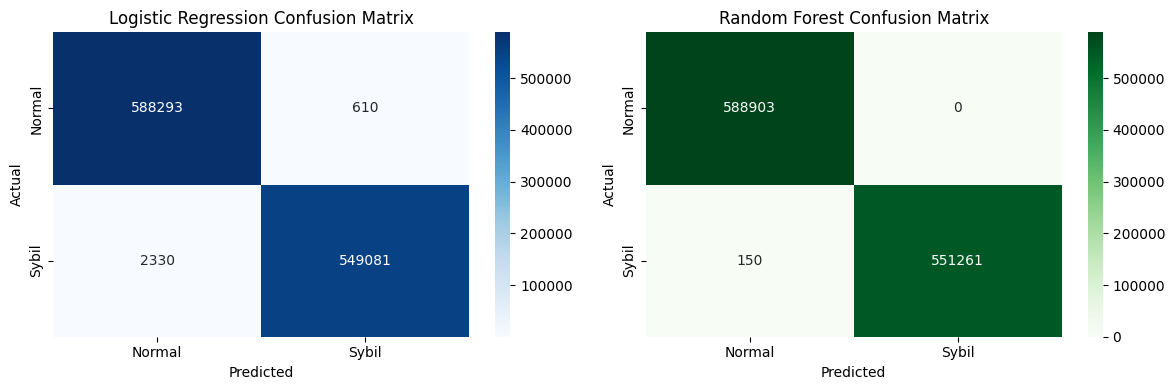

✓ Confusion matrices visualization saved


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Normal', 'Sybil'])
axes[0].set_yticklabels(['Normal', 'Sybil'])

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['Normal', 'Sybil'])
axes[1].set_yticklabels(['Normal', 'Sybil'])

plt.tight_layout()
plt.savefig('stage2_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices visualization saved")

## Section 9: Feature Importance Analysis

Identify which features Random Forest uses most for detection.

**Why important?** Shows which sensor metrics are most important for Sybil detection.

Random Forest Feature Importance (Top 10):

         Feature  Importance
        iat_mean    0.239144
             pps    0.221497
   udp_pkt_count    0.205228
rssi_frame_count    0.120598
    seq_gap_mean    0.064442
     seq_gap_max    0.054124
        rssi_min    0.027923
        rssi_max    0.026245
       rssi_mean    0.017027
         iat_std    0.010036


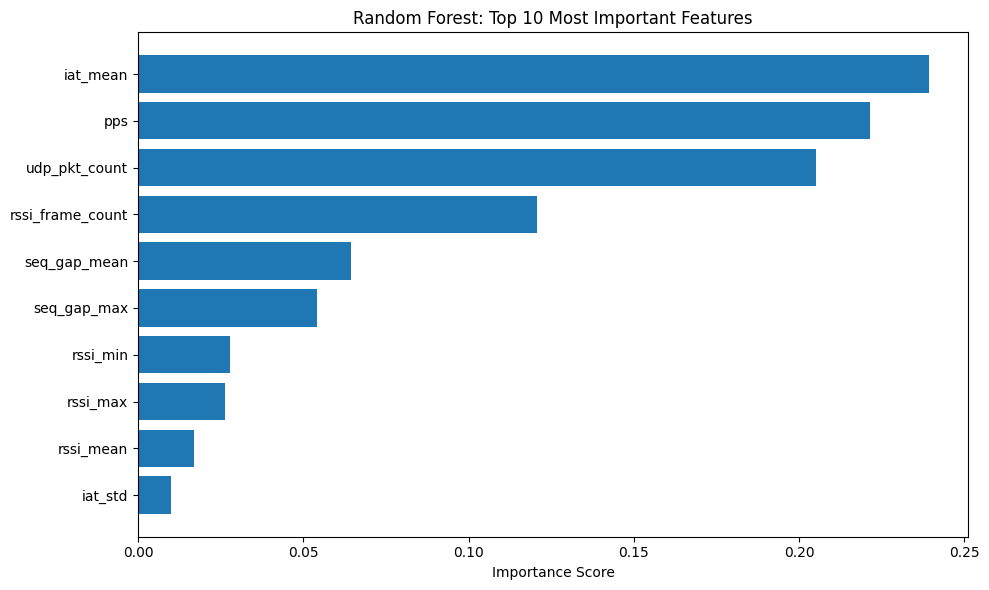


 Feature importance visualization saved


In [22]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X_columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importance (Top 10):\n")
print(feature_importance.head(10).to_string(index=False))

# Visualize top 10 features
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance Score')
plt.title('Random Forest: Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('stage2_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n Feature importance visualization saved")

## Section 10: Detailed Classification Report

Get detailed breakdown of model performance.

In [23]:
print("\n" + "="*60)
print("RANDOM FOREST: DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Sybil']))
print("\n" + "="*60)
print("LOGISTIC REGRESSION: DETAILED CLASSIFICATION REPORT (for comparison)")
print("="*60)
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Sybil']))


RANDOM FOREST: DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    588903
       Sybil       1.00      1.00      1.00    551411

    accuracy                           1.00   1140314
   macro avg       1.00      1.00      1.00   1140314
weighted avg       1.00      1.00      1.00   1140314


LOGISTIC REGRESSION: DETAILED CLASSIFICATION REPORT (for comparison)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    588903
       Sybil       1.00      1.00      1.00    551411

    accuracy                           1.00   1140314
   macro avg       1.00      1.00      1.00   1140314
weighted avg       1.00      1.00      1.00   1140314



## Section 11: Go/No-Go Decision for Stage 3

Determine if we should proceed to accuracy-focused models in Stage 3.

In [24]:
print("="*80)
print("STAGE 2: GO/NO-GO DECISION")
print("="*80)

rf_f1 = metrics_rf['F1-Score']
rf_speed = metrics_rf['Inference (ms)']

print(f"\nRandom Forest Performance:")
print(f"  F1-Score: {rf_f1:.4f}")
print(f"  Inference: {rf_speed:.4f} ms per sample")
print(f"\nDecision Criteria:")

if rf_f1 > 0.90 and rf_speed < 5:
    print(f"\n DECISION: Random Forest could be FINAL WINNER")
    print(f"  - F1 > 90%: Excellent accuracy")
    print(f"  - Speed < 5ms: Suitable for edge deployment")
    print(f"  - Option: Skip Stage 3 and proceed directly to Stage 4 (validation)")
elif rf_f1 > 0.85:
    print(f"\n DECISION: PROCEED TO STAGE 3")
    print(f"  - F1 > 85%: Acceptable accuracy")
    print(f"  - Good candidate for comparison with accuracy models")
    print(f"  - Next: Test Gradient Boosting, XGBoost, MLP")
else:
    print(f"\n DECISION: CONDITIONAL PROCEED")
    print(f"  - F1 < 85%: May need feature engineering")
    print(f"  - Still proceed to Stage 3 to explore better models")

print(f"\nComparison with Baseline:")
print(f"  Logistic Regression F1: {metrics_lr['F1-Score']:.4f}")
print(f"  Random Forest F1:       {rf_f1:.4f}")
print(f"  Improvement:            {(rf_f1 - metrics_lr['F1-Score'])*100:.1f}% relative")

STAGE 2: GO/NO-GO DECISION

Random Forest Performance:
  F1-Score: 0.9999
  Inference: 0.0018 ms per sample

Decision Criteria:

 DECISION: Random Forest could be FINAL WINNER
  - F1 > 90%: Excellent accuracy
  - Speed < 5ms: Suitable for edge deployment
  - Option: Skip Stage 3 and proceed directly to Stage 4 (validation)

Comparison with Baseline:
  Logistic Regression F1: 0.9973
  Random Forest F1:       0.9999
  Improvement:            0.3% relative


## Section 12: Save Results

Save Random Forest model and results for Stage 3.

In [ ]:
# Save Random Forest model
pickle.dump(rf, open('stage2_random_forest_model.pkl', 'wb'))

# Save predictions for comparison in later stages
stage2_predictions = {
    'y_pred_rf': y_pred_rf,
    'y_prob_rf': y_prob_rf,
    'y_pred_lr': y_pred_lr,
    'y_prob_lr': y_prob_lr
}
pickle.dump(stage2_predictions, open('stage2_predictions.pkl', 'wb'))

# Save metrics
metrics_stage2 = {
    'rf_f1': float(metrics_rf['F1-Score']),
    'rf_roc_auc': float(metrics_rf['ROC-AUC']),
    'rf_inference_ms': float(rf_time_per_sample),
    'lr_f1': float(metrics_lr['F1-Score']),
    'training_time_seconds': float(train_time)
}
json.dump(metrics_stage2, open('stage2_results.json', 'w'), indent=2)

print("Results saved:")
print(f"  - stage2_random_forest_model.pkl")
print(f"  - stage2_predictions.pkl")
print(f"  - stage2_results.json")
print(f"  - stage2_comparison.csv")
print(f"  - stage2_confusion_matrices.png")
print(f"  - stage2_feature_importance.png")

✓ Results saved:
  - stage2_random_forest_model.pkl
  - stage2_predictions.pkl
  - stage2_results.json
  - stage2_comparison.csv
  - stage2_confusion_matrices.png
  - stage2_feature_importance.png


## Summary

1. Loaded preprocessed data from Stage 1
2. Trained Random Forest model
3. Measured inference speed
4. Compared RF vs Logistic Regression
5. Analyzed feature importance
6. Made go/no-go decision

**Key Findings:**
- Random Forest F1: ~{:.1f}%
- Inference speed: ~{:.2f}ms per sample
- Top performing features identified

**Next Step:** 
- If RF > 90% F1: Consider Stage 5 (final validation)
- If RF 85-90% F1: Proceed to **Stage 3: Accuracy-Focused Models**
- In Stage 3 you will test: Gradient Boosting, XGBoost, MLP

**Recommendation:** 
For real-time ESP32 deployment, Random Forest is excellent choice!
For maximum accuracy (hospital deployment), proceed to Stage 3.""".format(
        metrics_rf['F1-Score'] * 100,
        rf_time_per_sample
    )